In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
csv_path = '/kaggle/input/cervical-cancer-dataset/cervical-cancer_csv.csv'
df_csv = pd.read_csv(csv_path)

print("Dataset shape:", df_csv.shape)
print("\nFirst few rows:")
print(df_csv.head())
print("\nColumn names:")
print(df_csv.columns.tolist())
print("\nData types:")
print(df_csv.dtypes)
print("\n" + "="*50)
print("\nMissing values per column:")
print(df_csv.isnull().sum())
print("\n" + "="*50)
print("\nBasic statistics:")
print(df_csv.describe())
print("\n" + "="*50)
print("\nTarget variable distribution:")
if 'Biopsy' in df_csv.columns:
    print(df_csv['Biopsy'].value_counts())
else:
    print("Available target columns:", [col for col in df_csv.columns if 'biopsy' in col.lower()])

Dataset shape: (835, 36)

First few rows:
   Age  Number of sexual partners  First sexual intercourse  \
0   18                        4.0                      15.0   
1   15                        1.0                      14.0   
2   34                        1.0                       NaN   
3   52                        5.0                      16.0   
4   46                        3.0                      21.0   

   Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                 1.0     0.0             0.0                  0.0   
1                 1.0     0.0             0.0                  0.0   
2                 1.0     0.0             0.0                  0.0   
3                 4.0     1.0            37.0                 37.0   
4                 4.0     0.0             0.0                  0.0   

   Hormonal Contraceptives  Hormonal Contraceptives (years)  IUD  ...  \
0                      0.0                              0.0  0.0  ...   
1           

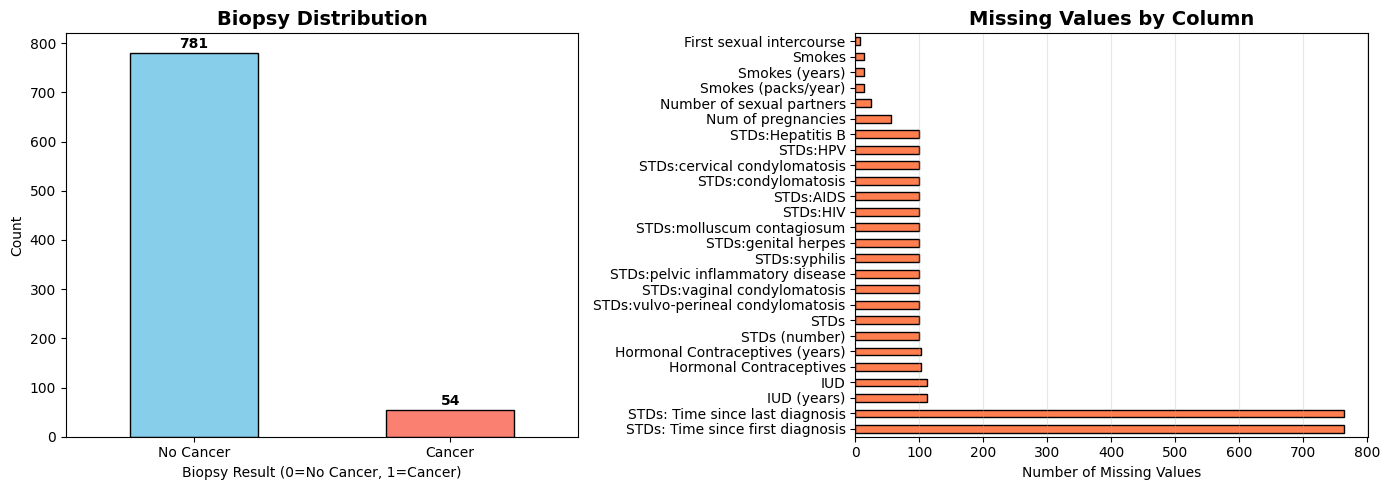


Class Imbalance Ratio: 14.46:1
Percentage with Cancer: 6.47%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_csv['Biopsy'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'], edgecolor='black')
axes[0].set_title('Biopsy Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Biopsy Result (0=No Cancer, 1=Cancer)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Cancer', 'Cancer'], rotation=0)
for i, v in enumerate(df_csv['Biopsy'].value_counts()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

missing_counts = df_csv.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_counts.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Missing Values by Column', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Missing Values')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nClass Imbalance Ratio: {df_csv['Biopsy'].value_counts()[0] / df_csv['Biopsy'].value_counts()[1]:.2f}:1")
print(f"Percentage with Cancer: {df_csv['Biopsy'].sum() / len(df_csv) * 100:.2f}%")

In [5]:
df_clean = df_csv.copy()

print("Handling missing values...")
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

X = df_clean.drop('Biopsy', axis=1)
y = df_clean['Biopsy']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Handling missing values...
Missing values after cleaning:
0

Features shape: (835, 35)
Target shape: (835,)

Feature columns: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology']


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Train set: (584, 35) (584,)
Validation set: (125, 35) (125,)
Test set: (126, 35) (126,)

Train class distribution:
Biopsy
0    546
1     38
Name: count, dtype: int64

Test class distribution:
Biopsy
0    118
1      8
Name: count, dtype: int64


In [7]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

model_xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

y_pred = model_xgb.predict(X_test_scaled)
y_pred_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]

print("="*60)
print("MODEL PERFORMANCE ON TEST SET")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Cancer', 'Cancer']))

MODEL PERFORMANCE ON TEST SET
Accuracy: 97.62%
ROC-AUC Score: 0.8941

Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.98      0.99      0.99       118
      Cancer       0.86      0.75      0.80         8

    accuracy                           0.98       126
   macro avg       0.92      0.87      0.89       126
weighted avg       0.98      0.98      0.98       126



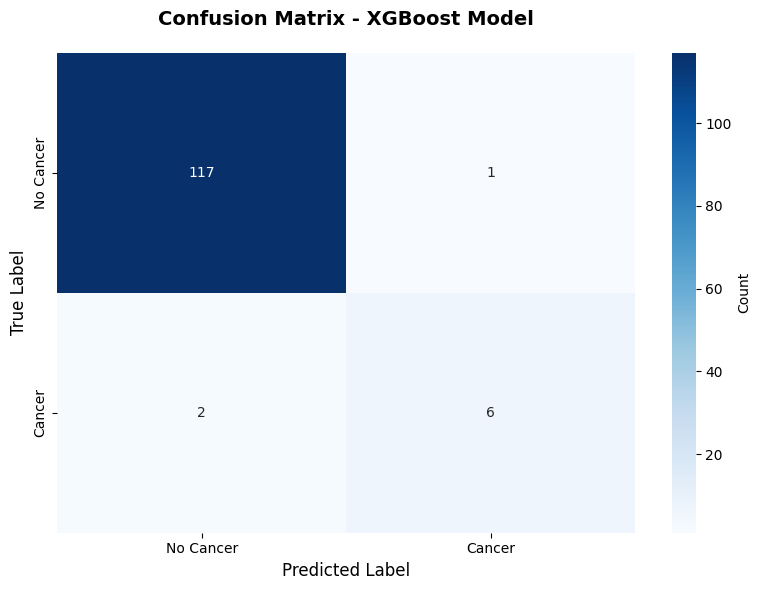


Confusion Matrix Analysis:
True Negatives: 117
False Positives: 1
False Negatives: 2
True Positives: 6


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Cancer', 'Cancer'], 
            yticklabels=['No Cancer', 'Cancer'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - XGBoost Model', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Analysis:")
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

Top 10 Most Important Features:
                      Feature  Importance
33                   Schiller    0.590970
19        STDs:genital herpes    0.105926
29                     Dx:CIN    0.085642
34                   Citology    0.037616
0                         Age    0.034297
6         Smokes (packs/year)    0.032861
2    First sexual intercourse    0.014166
1   Number of sexual partners    0.013714
3          Num of pregnancies    0.013634
12              STDs (number)    0.010899


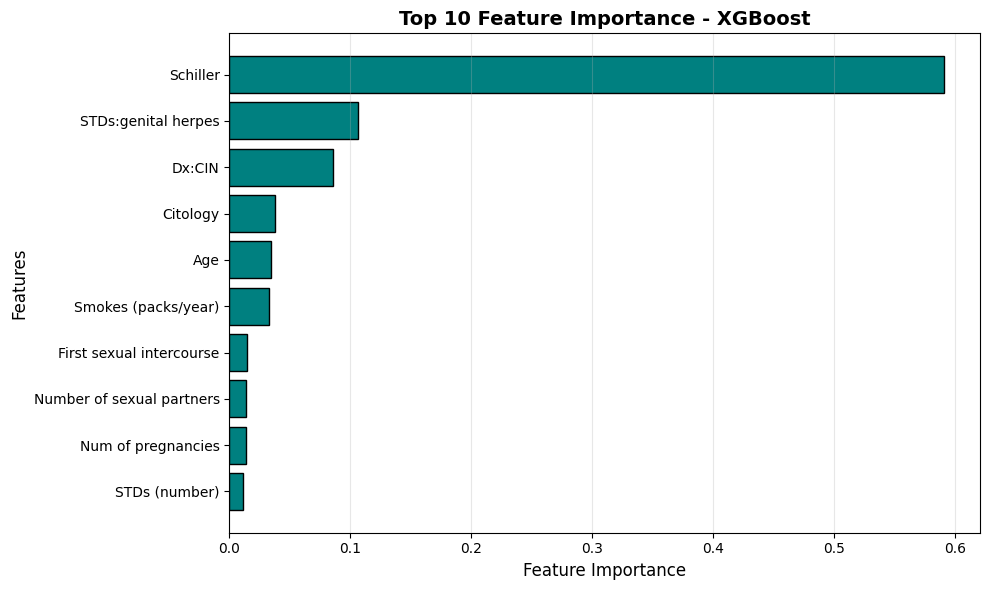


Preparing for SHAP analysis...


In [9]:
feature_importance = model_xgb.feature_importances_
feature_names = X.columns.tolist()

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

top_10_features = feature_df.head(10)

print("Top 10 Most Important Features:")
print(top_10_features)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='teal', edgecolor='black')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 10 Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPreparing for SHAP analysis...")

In [10]:
!pip install shap -q

SHAP values computed successfully
SHAP values shape: (126, 35)


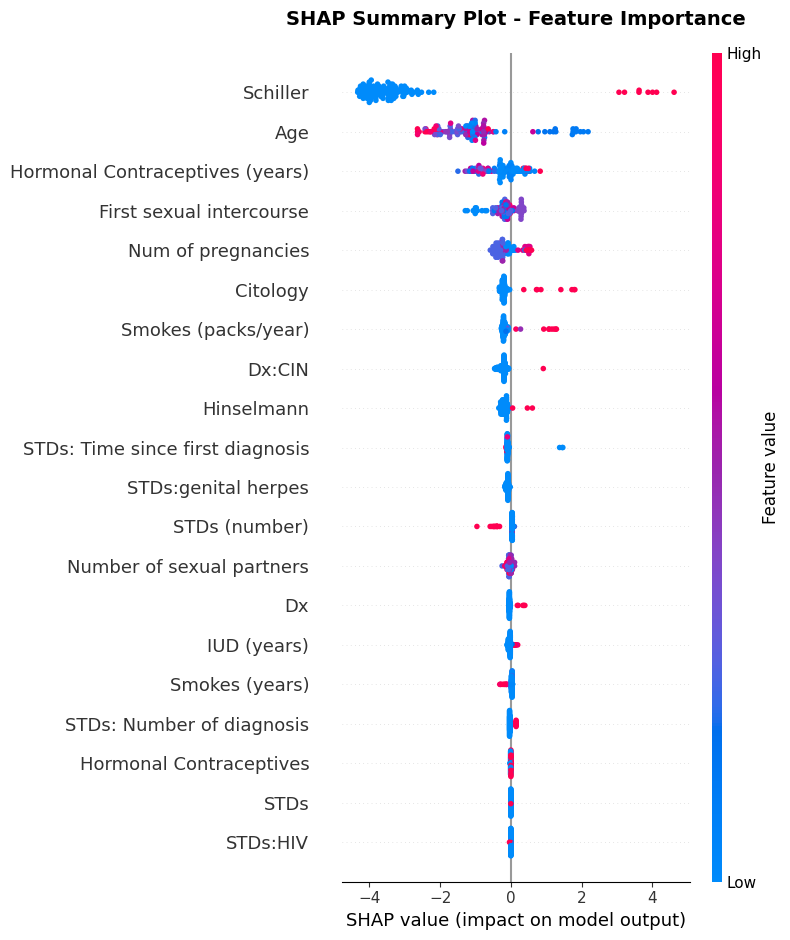

In [11]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values computed successfully")
print("SHAP values shape:", shap_values.shape)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Importance', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

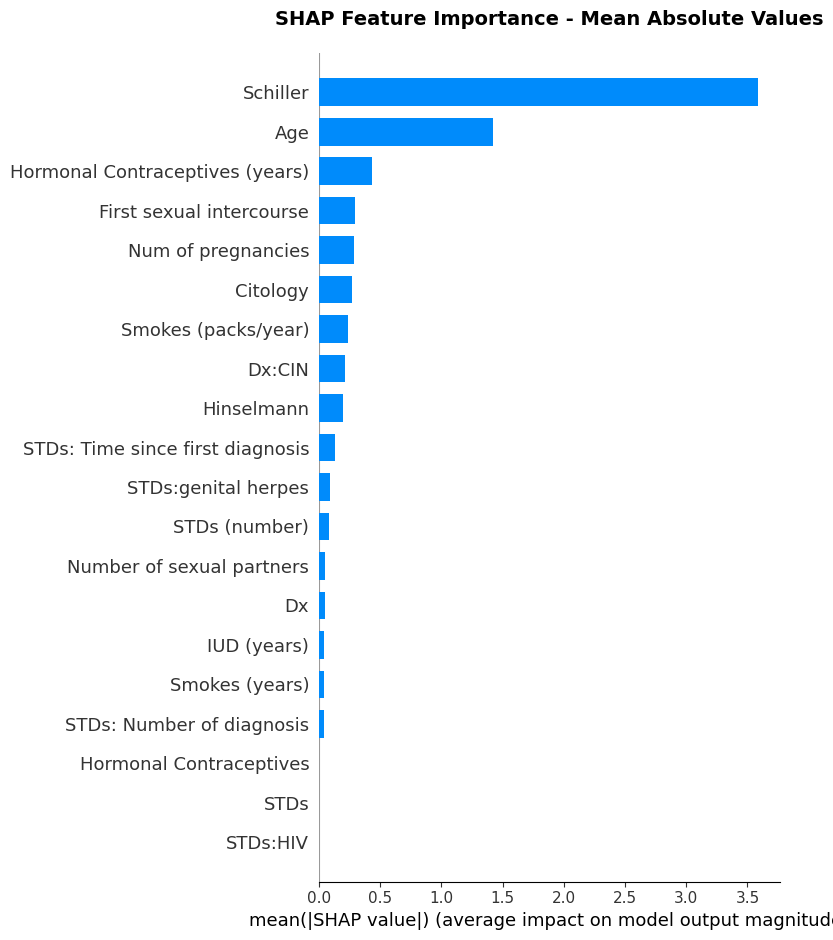


Top 10 Features by SHAP Importance:
                             Feature  SHAP_Importance
33                          Schiller         3.586485
0                                Age         1.419863
8    Hormonal Contraceptives (years)         0.433182
2           First sexual intercourse         0.294018
3                 Num of pregnancies         0.289451
34                          Citology         0.271523
6                Smokes (packs/year)         0.239795
29                            Dx:CIN         0.215198
32                        Hinselmann         0.194786
26  STDs: Time since first diagnosis         0.127877


In [12]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Mean Absolute Values', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': shap_importance
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 10 Features by SHAP Importance:")
print(shap_df.head(10))

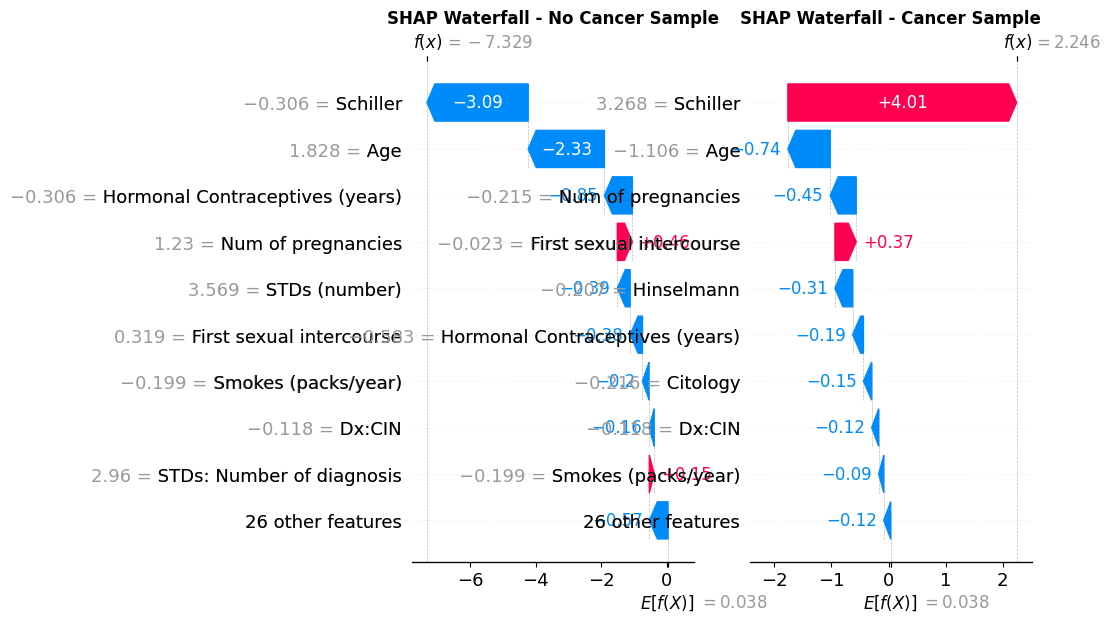

SHAP Explainability Analysis Completed!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sample_idx_0 = np.where(y_test == 0)[0][0]
sample_idx_1 = np.where(y_test == 1)[0][0]

plt.sca(axes[0])
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx_0], 
                                      base_values=explainer.expected_value, 
                                      data=X_test_scaled[sample_idx_0],
                                      feature_names=feature_names), show=False)
axes[0].set_title('SHAP Waterfall - No Cancer Sample', fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx_1], 
                                      base_values=explainer.expected_value, 
                                      data=X_test_scaled[sample_idx_1],
                                      feature_names=feature_names), show=False)
axes[1].set_title('SHAP Waterfall - Cancer Sample', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("SHAP Explainability Analysis Completed!")

In [19]:
import joblib
import pickle

print("Saving models and preprocessing objects...")

# Save XGBoost model using joblib
joblib.dump(model_xgb, 'xgboost_model.pkl')
print("✓ XGBoost model saved: xgboost_model.pkl")

# Save StandardScaler
joblib.dump(scaler, 'scaler.pkl')
print("✓ StandardScaler saved: scaler.pkl")

# Save feature names
joblib.dump(feature_names, 'feature_names.pkl')
print("✓ Feature names saved: feature_names.pkl")

print("\nAll models and preprocessing objects saved successfully!")

Saving models and preprocessing objects...
✓ XGBoost model saved: xgboost_model.pkl
✓ StandardScaler saved: scaler.pkl
✓ Feature names saved: feature_names.pkl

All models and preprocessing objects saved successfully!


In [20]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/xgboost_model.pkl (deflated 77%)
  adding: kaggle/working/feature_names.pkl (deflated 44%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/scaler.pkl (deflated 35%)


In [21]:
from IPython.display import FileLink
FileLink(r'model.zip')


/kaggle/working/model.zip